# HPO en dos fases

## Estructura general

### Fase A — HPO de hiperparámetros de entrenamiento
Se entrena con `riesgo=1.0` para obtener la señal más limpia posible (penalizaciones mínimas).
Se buscan los mejores valores de `gamma`, `tau`, `lr_actor`, `lr_criticos`, `lr_alpha`, `tamano_batch`.
Métrica de selección: **Sharpe en validación**.

### Fase B — HPO de lambdas por perfil de riesgo
Con la configuración ganadora de Fase A fija, se buscan los mejores lambdas para cada perfil:
`lambda_dd`, `lambda_varianza`, `lambda_correlacion`, `correlacion_objetivo`.

Cada perfil tiene su propia función de scoring:
- **conservador**: 50% Sharpe + 50% (1 - MDD normalizado)
- **normal**: 100% Sharpe
- **arriesgado**: 40% Sharpe + 60% CAGR
- **muy_arriesgado**: 20% Sharpe + 80% CAGR

Las métricas se normalizan al rango del HPO antes de ponderar.

## Imports y utilidades

In [1]:
from __future__ import annotations

import os
import sys
import copy
import json
import random
import inspect
from pathlib import Path
from itertools import product
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Entrenamiento_SAC import ConfigEntrenamiento, entrenar_sac
from entorno_cartera import EntornoCartera

In [2]:
def fijar_semillas(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def encontrar_carpeta_datos() -> Path:
    candidatos = [
        PROJECT_ROOT / "Datos",
        PROJECT_ROOT / "datos",
        PROJECT_ROOT / "datos_procesados",
    ]
    for carpeta in candidatos:
        if carpeta.exists():
            return carpeta
    raise FileNotFoundError(
        "No encuentro la carpeta de datos. Revisa PROJECT_ROOT."
    )


def cargar_split(carpeta_base: Path, nombre_split: str):
    carpeta_split = carpeta_base / nombre_split.capitalize()
    datos_estado = pd.read_csv(
        carpeta_split / f"datos_estado_{nombre_split}.csv",
        index_col=0, parse_dates=True
    )
    retornos = pd.read_csv(
        carpeta_split / f"retornos_{nombre_split}.csv",
        index_col=0, parse_dates=True
    )
    rf_semanal = pd.read_csv(
        carpeta_split / f"rf_semanal_{nombre_split}.csv",
        index_col=0, parse_dates=True
    ).squeeze("columns")
    return datos_estado, retornos, rf_semanal


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1 or len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

## Carga de datos

In [3]:
carpeta_datos = encontrar_carpeta_datos()

datos_estado_train, retornos_train, rf_semanal_train = cargar_split(carpeta_datos, "train")
datos_estado_val, retornos_val, rf_semanal_val = cargar_split(carpeta_datos, "validation")

# Covarianzas precalculadas sin leakage
cov_train = pd.read_csv(carpeta_datos / "Train" / "covarianzas_train.csv", index_col=0)
cov_val   = pd.read_csv(carpeta_datos / "Validation" / "covarianzas_validation.csv", index_col=0)

print("Carpeta datos:", carpeta_datos)
print("Train:", datos_estado_train.shape, retornos_train.shape, rf_semanal_train.shape)
print("Validation:", datos_estado_val.shape, retornos_val.shape, rf_semanal_val.shape)
print("Cov train:", cov_train.shape, "| Cov val:", cov_val.shape)

Carpeta datos: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/Datos
Train: (574, 144) (574, 16) (574,)
Validation: (209, 144) (209, 16) (209,)
Cov train: (16, 16) | Cov val: (16, 16)


## Configuración base y perfiles

In [ ]:
# ------------------------------------------------------------------
# PERFILES DE RIESGO (Fase B)
# ------------------------------------------------------------------
PERFILES_RIESGO = {
    "muy_conservador": 0.10,
    "conservador":     0.30,
    "normal":          0.50,
    "arriesgado":      0.70,
    "muy_arriesgado":  0.90,
}

# ------------------------------------------------------------------
# CONFIG BASE — valores fijos que no se tocan en el HPO
# ------------------------------------------------------------------
base_config = {
    "semilla":                    43,
    "pasos_totales":              50_000,
    "gamma":                      0.9,
    "tau":                        0.01,
    "lr_actor":                   1e-4,
    "lr_criticos":                3e-4,
    "lr_alpha":                   1e-4,
    "tamano_batch":               256,
    "tamano_buffer":              50_000,
    "pasos_warmup":               2_000,
    "frecuencia_actualizacion":   2,
    "actualizaciones_por_step":   2,   # reducido de 4 para evitar sobreentrenamiento
    "reward_scale":               20.0,
    "offset_target_entropy":      0.0,
    "max_concentracion_total_extra": 5.0,
    "ventana_log_recompensa":     1_000,
    "frecuencia_log":             1_000,
    "target_entropy":             -8.0,  
    "riesgo":                     1.0,   # se sobreescribe por perfil en Fase B
}

# ------------------------------------------------------------------
# CONTROL GENERAL
# ------------------------------------------------------------------
N_RUNS_POR_CONFIG   = 1
SEED_BASE           = 43
TOP_K_FINALISTAS    = 3

# Cartera inicial equiponderada para validación (igual para todos los perfiles)
N_ACTIVOS_TOTALES = retornos_train.shape[1] + 1  # activos de riesgo + cash
cartera_inicial_validacion = np.ones(N_ACTIVOS_TOTALES) / N_ACTIVOS_TOTALES

print(f"N_ACTIVOS_TOTALES: {N_ACTIVOS_TOTALES}")
print(f"target_entropy: {base_config['target_entropy']}")
print(f"cartera_inicial_validacion (suma): {cartera_inicial_validacion.sum():.4f}")

N_ACTIVOS_TOTALES: 17
target_entropy: -2
cartera_inicial_validacion (suma): 1.0000


## Funciones auxiliares: entorno, entrenamiento, métricas

In [5]:
def construir_entorno(
    datos_estado: pd.DataFrame,
    retornos: pd.DataFrame,
    rf_semanal: pd.Series,
    riesgo: float,
    covarianzas_iniciales: pd.DataFrame | None = None,
) -> EntornoCartera:
    kwargs = dict(
        datos_estado=datos_estado,
        retornos_semanales=retornos,
        rf_semanal=rf_semanal,
        coste_transaccion=0.001,
        valor_inicial=1000.0,
        covarianzas_iniciales=covarianzas_iniciales,
    )
    firma = inspect.signature(EntornoCartera)
    for nombre in ["riesgo", "perfil_riesgo", "riesgo_usuario", "score_riesgo", "nivel_riesgo"]:
        if nombre in firma.parameters:
            kwargs[nombre] = float(riesgo)
            break
    return EntornoCartera(**kwargs)


def build_train_config(config: Dict[str, Any]) -> ConfigEntrenamiento:
    return ConfigEntrenamiento(
        semilla=int(config["semilla"]),
        pasos_totales=int(config["pasos_totales"]),
        gamma=float(config["gamma"]),
        tau=float(config["tau"]),
        lr_actor=float(config["lr_actor"]),
        lr_criticos=float(config["lr_criticos"]),
        lr_alpha=float(config["lr_alpha"]),
        tamano_batch=int(config["tamano_batch"]),
        tamano_buffer=int(config["tamano_buffer"]),
        pasos_warmup=int(config["pasos_warmup"]),
        frecuencia_actualizacion=int(config["frecuencia_actualizacion"]),
        actualizaciones_por_step=int(config["actualizaciones_por_step"]),
        reward_scale=float(config["reward_scale"]),
        target_entropy=(
            None if config.get("target_entropy") is None
            else float(config["target_entropy"])
        ),
        offset_target_entropy=float(config["offset_target_entropy"]),
        max_concentracion_total_extra=float(config["max_concentracion_total_extra"]),
        ventana_log_recompensa=int(config["ventana_log_recompensa"]),
        frecuencia_log=int(config["frecuencia_log"]),
    )


def politica_determinista(agente, device):
    def fn(estado_np):
        estado_t = torch.as_tensor(
            estado_np, dtype=torch.float32, device=device
        ).unsqueeze(0)
        with torch.no_grad():
            accion = agente.seleccionar_accion(estado_t, determinista=True)
        return accion.squeeze(0).detach().cpu().numpy().astype(np.float64)
    return fn

In [6]:
METRICAS_TRAIN = [
    "recompensas", "perdida_critic1", "perdida_critic2",
    "perdida_actor", "alpha", "gap_critics",
    "log_prob_std", "concentracion_total", "peso_cash",
]


def calcular_metricas_financieras(
    valor_cartera: pd.Series,
    rf_semanal: pd.Series,
    pesos: pd.DataFrame = None,
) -> Dict[str, float]:
    valor_cartera = valor_cartera.astype(float).dropna()
    rend = valor_cartera.pct_change().dropna()

    nan_dict = {k: np.nan for k in [
        "valor_final", "retorno_total", "cagr", "volatilidad_anual",
        "sharpe", "sortino", "max_drawdown", "calmar",
        "turnover", "peso_cash_medio", "exposicion_media", "n_activos_medio"
    ]}

    if valor_cartera.empty or len(valor_cartera) < 2 or rend.empty:
        return nan_dict

    rf_alineado = rf_semanal.reindex(rend.index).ffill().fillna(0.0)
    exceso = rend - rf_alineado

    valor_inicial = float(valor_cartera.iloc[0])
    valor_final   = float(valor_cartera.iloc[-1])
    retorno_total = valor_final / valor_inicial - 1.0
    n     = len(rend)
    cagr  = (valor_final / valor_inicial) ** (52 / n) - 1.0
    vol   = rend.std() * np.sqrt(52)
    sharpe = exceso.mean() / exceso.std() * np.sqrt(52) if exceso.std() > 0 else np.nan

    downside = rend[rend < 0]
    sortino  = rend.mean() / downside.std() * np.sqrt(52) if len(downside) > 0 else np.nan

    acumulado = (1 + rend).cumprod()
    max_dd    = (acumulado / acumulado.cummax() - 1.0).min()
    calmar    = cagr / abs(max_dd) if max_dd != 0 else np.nan

    turnover = peso_cash_medio = exposicion_media = n_activos_medio = np.nan
    if pesos is not None:
        turnover = pesos.diff().abs().sum(axis=1).mean()
        if "cash" in pesos.columns:
            peso_cash_medio  = pesos["cash"].mean()
            exposicion_media = 1 - peso_cash_medio
        n_activos_medio = (pesos > 1e-3).sum(axis=1).mean()

    return {
        "valor_final": valor_final, "retorno_total": retorno_total,
        "cagr": cagr, "volatilidad_anual": vol,
        "sharpe": sharpe, "sortino": sortino,
        "max_drawdown": max_dd, "calmar": calmar,
        "turnover": turnover, "peso_cash_medio": peso_cash_medio,
        "exposicion_media": exposicion_media, "n_activos_medio": n_activos_medio,
    }


def evaluar_en_validation(
    agente,
    config: Dict[str, Any],
    datos_estado_val: pd.DataFrame,
    retornos_val: pd.DataFrame,
    rf_semanal_val: pd.Series,
    pesos_iniciales: np.ndarray | None = None,
) -> Tuple[pd.Series, Dict[str, float]]:
    entorno_val = construir_entorno(
        datos_estado=datos_estado_val,
        retornos=retornos_val,
        rf_semanal=rf_semanal_val,
        riesgo=config["riesgo"],
        covarianzas_iniciales=cov_val,
    )
    device = next(agente.actor.parameters()).device
    fn_pesos = politica_determinista(agente, device)

    backtest_df = entorno_val.ejecutar_backtest(
        funcion_pesos=fn_pesos,
        pesos_iniciales=pesos_iniciales,
    )

    metricas = calcular_metricas_financieras(
        valor_cartera=backtest_df["valor_cartera"],
        rf_semanal=rf_semanal_val,
        pesos=backtest_df,
    )

    print(
        f"Sharpe={metricas['sharpe']:.4f} | "
        f"CAGR={metricas['cagr']:.4%} | "
        f"MDD={metricas['max_drawdown']:.4%}"
    )
    return backtest_df["valor_cartera"], metricas


def history_to_long_df(history, experiment_id, config_id, run_id):
    max_len = max(len(v) for v in history.values()) if history else 0
    rows = []
    for step_idx in range(max_len):
        row = {"experiment_id": experiment_id, "config_id": config_id,
               "run_id": run_id, "step_idx": step_idx}
        for k, v in history.items():
            row[k] = v[step_idx] if step_idx < len(v) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def build_summary_row_train(df_run, tail_fraction=0.2):
    out = {}
    n = len(df_run)
    tail_n = max(1, int(np.ceil(n * tail_fraction)))
    tail_df = df_run.tail(tail_n)
    for m in METRICAS_TRAIN:
        if m in df_run.columns:
            out[f"{m}_mean_tail"] = float(tail_df[m].mean())
            out[f"{m}_std_tail"]  = float(tail_df[m].std(ddof=1)) if len(tail_df) > 1 else 0.0
            out[f"{m}_last"]      = float(df_run[m].dropna().iloc[-1]) if df_run[m].dropna().size > 0 else np.nan
    return out

In [7]:
def train_one_run(
    config: Dict[str, Any],
    datos_estado_train: pd.DataFrame,
    retornos_train: pd.DataFrame,
    rf_semanal_train: pd.Series,
    datos_estado_val: pd.DataFrame,
    retornos_val: pd.DataFrame,
    rf_semanal_val: pd.Series,
):
    fijar_semillas(int(config["semilla"]))

    entorno_train = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=config["riesgo"],
        covarianzas_iniciales=cov_train,
    )

    cfg_train = build_train_config(config)

    history, agente = entrenar_sac(
        entorno=entorno_train,
        config=cfg_train,
        devolver_agente=True,
        riesgo=config["riesgo"],
    )

    serie_valor_val, metricas_val = evaluar_en_validation(
        agente=agente,
        config=config,
        datos_estado_val=datos_estado_val,
        retornos_val=retornos_val,
        rf_semanal_val=rf_semanal_val,
        pesos_iniciales=cartera_inicial_validacion,
    )

    return history, serie_valor_val, metricas_val, agente


def generar_combinaciones(search_spaces: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    claves = list(search_spaces.keys())
    return [
        dict(zip(claves, combo))
        for combo in product(*[search_spaces[k] for k in claves])
    ]


def run_full_grid(
    search_spaces: Dict[str, List[Any]],
    base_config: Dict[str, Any],
    n_runs: int = 1,
    seed_start: int = SEED_BASE,
):
    combinaciones = generar_combinaciones(search_spaces)
    all_logs, resumen_rows, curvas_validation = [], [], {}

    for idx, combo in enumerate(combinaciones, start=1):
        config_id = f"cfg_{idx:03d}"
        curvas_validation[config_id] = []
        print("=" * 80)
        print(f"Configuración {idx}/{len(combinaciones)} -> {config_id}")
        print(combo)

        for run_id in range(n_runs):
            cfg = copy.deepcopy(base_config)
            cfg.update(combo)
            cfg["semilla"] = seed_start + run_id

            experiment_id = f"{config_id}|run={run_id}"
            history, serie_val, metricas_val, agente = train_one_run(
                config=cfg,
                datos_estado_train=datos_estado_train,
                retornos_train=retornos_train,
                rf_semanal_train=rf_semanal_train,
                datos_estado_val=datos_estado_val,
                retornos_val=retornos_val,
                rf_semanal_val=rf_semanal_val,
            )

            df_run = history_to_long_df(history, experiment_id, config_id, run_id)
            for k, v in cfg.items():
                df_run[k] = v

            all_logs.append(df_run)
            curvas_validation[config_id].append(serie_val)

            row = {"experiment_id": experiment_id, "config_id": config_id, "run_id": run_id}
            row.update(cfg)
            row.update(build_summary_row_train(df_run))
            row.update(metricas_val)
            resumen_rows.append(row)

    logs_df    = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()
    resumen_df = pd.DataFrame(resumen_rows)
    return logs_df, resumen_df, curvas_validation

---
# FASE A — HPO de hiperparámetros de entrenamiento

Se usa `riesgo=1.0` para obtener la señal más limpia (penalizaciones mínimas).  
Métrica de selección: **Sharpe en validación**.  
Los lambdas del entorno NO se tocan aquí.

In [8]:
# ------------------------------------------------------------------
# Espacio de búsqueda Fase A
# ------------------------------------------------------------------
search_spaces_A = {
    "gamma":        [0.90, 0.95],
    "tau":          [0.02, 0.05],
    "lr_actor":     [3e-4, 1e-3],
    "lr_criticos":  [5e-4, 1e-3],
}

# Config base para Fase A: riesgo fijo a 1.0
base_config_A = copy.deepcopy(base_config)
base_config_A["riesgo"] = 1.0

n_combinaciones_A = int(np.prod([len(v) for v in search_spaces_A.values()]))
print(f"Parámetros Fase A: {list(search_spaces_A.keys())}")
print(f"Número total de combinaciones: {n_combinaciones_A}")
if n_combinaciones_A > 50:
    print("⚠️  Grid grande. Considera reducir valores para una exploración más rápida.")

Parámetros Fase A: ['gamma', 'tau', 'lr_actor', 'lr_criticos']
Número total de combinaciones: 16


In [9]:
import redes_neuronales
print(redes_neuronales.__file__)

import inspect
actor_src = inspect.getsource(redes_neuronales.Actor._weights_from_logits)
print(actor_src)

/Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/redes_neuronales.py
    def _weights_from_logits(self, logits: torch.Tensor) -> torch.Tensor:
        # Centramos logits para estabilidad numérica
        logits_centrados = logits - logits.mean(dim=-1, keepdim=True)

        # Softmax con temperatura
        pesos_soft = torch.softmax(logits_centrados / self.temperature, dim=-1)

        # Mezcla con uniforme
        if self.eps_mix_uniforme > 0.0:
            uniforme = torch.full_like(pesos_soft, 1.0 / self.act_dim)
            pesos = (1.0 - self.eps_mix_uniforme) * pesos_soft + self.eps_mix_uniforme * uniforme
        else:
            pesos = pesos_soft

        # Mezcla con uniforme para garantizar masa mínima en todos los activos
        # Esto evita que softmax colapse a peso=1 con mu muy grandes,
        # lo que hace que el clamp posterior no pueda redistribuir
        eps_piso = 1.0 / (self.act_dim * 2)  # piso mínimo ~3% con 17 activos
    

In [11]:
print(" = " * 40)
print("FASE A — HPO hiperparámetros de entrenamiento (riesgo=1.0)")
print(" = " * 40)

logs_A, resumen_A, curvas_A = run_full_grid(
    search_spaces=search_spaces_A,
    base_config=base_config_A,
    n_runs=N_RUNS_POR_CONFIG,
    seed_start=SEED_BASE,
)

 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE A — HPO hiperparámetros de entrenamiento (riesgo=1.0)
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Configuración 1/16 -> cfg_001
{'gamma': 0.9, 'tau': 0.02, 'lr_actor': 0.0003, 'lr_criticos': 0.0005}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0376  max=-0.0016  media=-1.8812
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -6.4911  (target_entropy=-2.0000)
  residual inicial: -4.4911  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0768
[CARTERA ACTUAL]
cash=0.076 | exposicion=0.924 | peso_max=0.151 | n_activos>1%=15 | top=SHY=0.151 | ^GSPC=0.132 | FEZ=0.118 | XLE=0.111 | LQD=0.082
retorno=-0.001607 | pen_total=+0.001559 | reward=-0.003704 | dd=0.0587 | vol=0.013370 | cash=0.076 | riesgo=1.00 || pen_dd=0.000587 | pen_varianza=0.000435 | pen_correlacion=0.

KeyboardInterrupt: 


Top 3 configuraciones Fase A (score = 40% Sharpe + 60% CAGR norm.):


,config_id,score_A,sharpe,cagr,max_drawdown,gamma,tau,lr_actor,lr_criticos,tamano_batch
0,cfg_002,1.000000,1.679100,0.159713,-0.067092,0.9,0.02,0.0003,0.0010,256
1,cfg_001,0.684687,1.097897,0.129537,-0.061534,0.9,0.02,0.0003,0.0005,256
2,cfg_003,0.591245,0.903905,0.125153,-0.177087,0.9,0.02,0.0010,0.0005,256



Tabla completa ordenada por score:


,config_id,score_A,sharpe,cagr,max_drawdown,gamma,tau,lr_actor,lr_criticos,tamano_batch
0,cfg_002,1.000000,1.679100,0.159713,-0.067092,0.90,0.02,0.0003,0.0010,256
1,cfg_001,0.684687,1.097897,0.129537,-0.061534,0.90,0.02,0.0003,0.0005,256
2,cfg_003,0.591245,0.903905,0.125153,-0.177087,0.90,0.02,0.0010,0.0005,256
3,cfg_014,0.588343,0.992763,0.105135,-0.119477,0.95,0.05,0.0003,0.0010,256
4,cfg_015,0.581960,0.956606,0.109635,-0.119850,0.95,0.05,0.0010,0.0005,256
5,cfg_006,0.545534,0.903735,0.103159,-0.127298,0.90,0.05,0.0003,0.0010,256
6,cfg_005,0.527765,0.932549,0.088558,-0.082577,0.90,0.05,0.0003,0.0005,256
7,cfg_004,0.491440,0.799282,0.098976,-0.142335,0.90,0.02,0.0010,0.0010,256
8,cfg_010,0.448377,0.825789,0.072669,-0.096762,0.95,0.02,0.0003,0.0010,256
9,cfg_016,0.423201,0.741892,0.078115,-0.146784,0.95,0.05,0.0010,0.0010,256


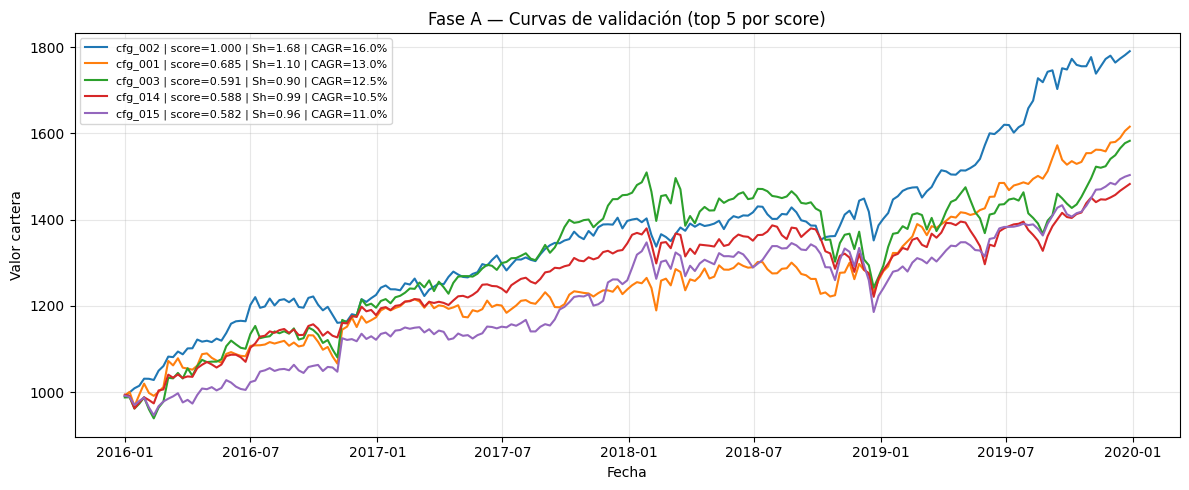

In [ ]:
# ------------------------------------------------------------------
# Análisis resultados Fase A — scoring 40% Sharpe + 60% CAGR (normalizados)
# ------------------------------------------------------------------

def scoring_fase_A(df):
    s = df["sharpe"].fillna(-999)
    c = df["cagr"].fillna(-999)

    def norm(x):
        mn, mx = x.min(), x.max()
        if mx == mn:
            return np.zeros(len(x))
        return (x - mn) / (mx - mn)

    return 0.7 * norm(s) + 0.3 * norm(c)


cols_show_A = [
    "config_id", "score_A", "sharpe", "cagr", "max_drawdown",
    "gamma", "tau", "lr_actor", "lr_criticos", "tamano_batch",
]

scores = scoring_fase_A(resumen_A)
resumen_A_ordenado = resumen_A.copy()
resumen_A_ordenado["score_A"] = scores
resumen_A_ordenado = resumen_A_ordenado.sort_values(
    "score_A", ascending=False
).reset_index(drop=True)

print(f"\nTop {TOP_K_FINALISTAS} configuraciones Fase A (score = 40% Sharpe + 60% CAGR norm.):")
display(resumen_A_ordenado[[c for c in cols_show_A if c in resumen_A_ordenado.columns]].head(TOP_K_FINALISTAS))

print("\nTabla completa ordenada por score:")
display(resumen_A_ordenado[[c for c in cols_show_A if c in resumen_A_ordenado.columns]])

plt.figure(figsize=(12, 5))
for _, row in resumen_A_ordenado.head(5).iterrows():
    cfg_id = row["config_id"]
    if cfg_id in curvas_A and curvas_A[cfg_id]:
        serie = curvas_A[cfg_id][0]
        plt.plot(
            serie.index, serie.values,
            label=f"{cfg_id} | score={row['score_A']:.3f} | Sh={row['sharpe']:.2f} | CAGR={row['cagr']:.1%}"
        )
plt.title("Fase A — Curvas de validación (top 5 por score)")
plt.xlabel("Fecha")
plt.ylabel("Valor cartera")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Top 3 configuraciones Fase A (riesgo=1.0):


,config_id,sharpe,cagr,max_drawdown,gamma,tau,lr_actor,lr_criticos,tamano_batch
0,cfg_002,1.679100,0.159713,-0.067092,0.90,0.02,0.0003,0.0010,256
1,cfg_001,1.097897,0.129537,-0.061534,0.90,0.02,0.0003,0.0005,256
2,cfg_014,0.992763,0.105135,-0.119477,0.95,0.05,0.0003,0.0010,256


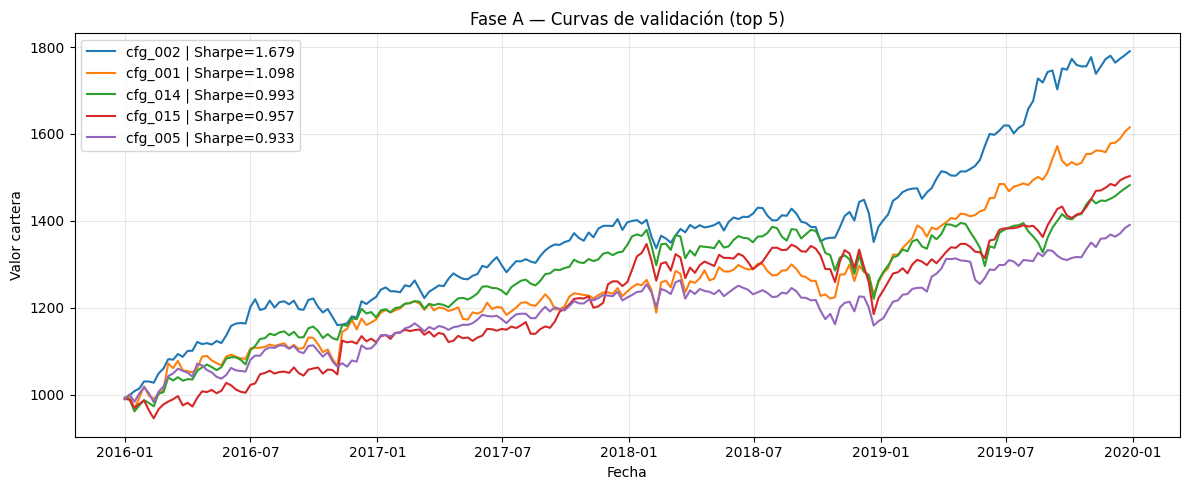

In [ ]:
# ------------------------------------------------------------------
# Análisis resultados Fase A — selección por Sharpe
# ------------------------------------------------------------------
cols_show_A = [
    "config_id", "sharpe", "cagr", "max_drawdown",
    "gamma", "tau", "lr_actor", "lr_criticos", "tamano_batch",
]

resumen_A_ordenado = resumen_A.sort_values(
    by=["sharpe", "cagr"], ascending=[False, False]
).reset_index(drop=True)

print(f"\nTop {TOP_K_FINALISTAS} configuraciones Fase A (riesgo=1.0):")
display(resumen_A_ordenado[cols_show_A].head(TOP_K_FINALISTAS))

# Gráfico curvas de validación — top 5
plt.figure(figsize=(12, 5))
for i, cfg_id in enumerate(resumen_A_ordenado["config_id"].head(5).values):
    if cfg_id in curvas_A and curvas_A[cfg_id]:
        serie = curvas_A[cfg_id][0]
        sharpe_val = resumen_A_ordenado.loc[
            resumen_A_ordenado["config_id"] == cfg_id, "sharpe"
        ].values[0]
        plt.plot(serie.index, serie.values, label=f"{cfg_id} | Sharpe={sharpe_val:.3f}")
plt.title("Fase A — Curvas de validación (top 5)")
plt.xlabel("Fecha")
plt.ylabel("Valor cartera")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Extraer configuración ganadora de Fase A
# ------------------------------------------------------------------
params_entrenamiento = ["gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha", "tamano_batch"]

ganador_A = resumen_A_ordenado.iloc[0]
config_ganadora_A = {p: ganador_A[p] for p in params_entrenamiento if p in ganador_A.index}

print("\n✅ Configuración ganadora Fase A:")
for k, v in config_ganadora_A.items():
    print(f"   {k:20s} = {v}")
print(f"   Sharpe en val      = {ganador_A['sharpe']:.4f}")
print(f"   CAGR en val        = {ganador_A['cagr']:.4%}")
print(f"   MDD en val         = {ganador_A['max_drawdown']:.4%}")


✅ Configuración ganadora Fase A:
   gamma                = 0.9
   tau                  = 0.02
   lr_actor             = 0.0003
   lr_criticos          = 0.001
   lr_alpha             = 0.0001
   tamano_batch         = 256
   Sharpe en val      = 1.6791
   CAGR en val        = 15.9713%
   MDD en val         = -6.7092%


---
# FASE B — HPO de lambdas por perfil de riesgo

Con la configuración de entrenamiento ganadora de Fase A fija,  
se buscan los mejores lambdas para cada perfil.

**Función de scoring por perfil (métricas normalizadas al rango del HPO):**

| Perfil | Fórmula |
|---|---|
| conservador | `0.5·sharpe_norm + 0.5·(1 - mdd_norm)` |
| normal | `1.0·sharpe_norm` |
| arriesgado | `0.4·sharpe_norm + 0.6·cagr_norm` |
| muy_arriesgado | `0.2·sharpe_norm + 0.8·cagr_norm` |

Donde `mdd_norm = |mdd| / max(|mdd|)` y `cagr_norm = cagr / max(cagr)` sobre todos los runs del perfil.

In [ ]:
# ------------------------------------------------------------------
# Espacio de búsqueda Fase B — 3 lambdas únicos
# ------------------------------------------------------------------
# Cada lambda define el máximo (conservador). El mínimo se deriva
# internamente en el entorno con ratios fijos:
#   lambda_dd_min          = lambda_dd          * 0.025
#   lambda_varianza_min    = lambda_varianza     * 0.01
#   lambda_correlacion_min = lambda_correlacion  * 0.05
#
# Esto reproduce exactamente los rangos anteriores con un único parámetro.
# lambda_turnover y lambda_concentracion son fijos, no se buscan.
# correlacion_objetivo_min/max son fijos (0.15 / 0.70).
# ------------------------------------------------------------------

search_spaces_B = {
    "lambda_dd":          [0.20, 0.60],
    "lambda_varianza":    [0.10, 0.30],
    "lambda_correlacion": [0.20],
}

PARAMS_LAMBDA = ["lambda_dd", "lambda_varianza", "lambda_correlacion"]

n_combinaciones_B = int(np.prod([len(v) for v in search_spaces_B.values()]))
print(f"Parámetros Fase B: {list(search_spaces_B.keys())}")
print(f"Combinaciones por perfil: {n_combinaciones_B}  (3³ = 27)")
print(f"Total runs (5 perfiles × {n_combinaciones_B} × {N_RUNS_POR_CONFIG} run): {n_combinaciones_B * len(PERFILES_RIESGO) * N_RUNS_POR_CONFIG}")

Parámetros Fase B: ['lambda_dd', 'lambda_varianza', 'lambda_correlacion']
Combinaciones por perfil: 4  (3³ = 27)
Total runs (5 perfiles × 4 × 1 run): 20


In [ ]:
# ------------------------------------------------------------------
# Función de scoring por perfil
# ------------------------------------------------------------------

def calcular_scores_perfil(
    resumen_df: pd.DataFrame,
    perfil: str,
) -> pd.Series:
    """
    Calcula el score compuesto para cada run del HPO de un perfil dado.
    Las métricas se normalizan al rango [0, 1] antes de ponderar.
    """
    df = resumen_df.copy()

    # Proteger contra NaN
    df["sharpe"]       = df["sharpe"].fillna(-999)
    df["cagr"]         = df["cagr"].fillna(-999)
    df["max_drawdown"] = df["max_drawdown"].fillna(-999)

    # Normalizar al rango del HPO
    def norm_01(s, invert=False):
        mn, mx = s.min(), s.max()
        if mx == mn:
            return pd.Series(np.zeros(len(s)), index=s.index)
        n = (s - mn) / (mx - mn)
        return 1 - n if invert else n

    sharpe_norm = norm_01(df["sharpe"])
    cagr_norm   = norm_01(df["cagr"])
    # mdd es negativo: más negativo = peor, así que invertimos
    mdd_norm    = norm_01(df["max_drawdown"].abs(), invert=False)  # abs(mdd) normalizado

    if perfil == 'muy_conservador':
        score = 0.15 * sharpe_norm + 0.05 * cagr_norm + 0.8 * (1 - mdd_norm)
    elif perfil == "conservador":
        # Quiere bajo drawdown, buen Sharpe y algo de rentabilidad, por ese orden
        score = 0.3 * sharpe_norm + 0.1 * cagr_norm + 0.6 * (1 - mdd_norm)
    elif perfil == "normal":
        # Maximizar eficiencia ajustada a riesgo
        score = 0.8 * sharpe_norm + 0.1 * cagr_norm + 0.1 * (1 - mdd_norm)
    elif perfil == "arriesgado":
        # Balance: algo de Sharpe + bastante CAGR
        score = 0.3 * sharpe_norm + 0.6 * cagr_norm + 0.1 * (1 - mdd_norm)
    elif perfil == "muy_arriesgado":
        # Maximizar crecimiento absoluto, poco peso al Sharpe
        score = 0.15 * sharpe_norm + 0.8 * cagr_norm + 0.05 * (1 - mdd_norm)
    else:
        # Default: Sharpe
        score = sharpe_norm

    return score


# Test rápido
print("Función de scoring definida correctamente.")
print("Perfiles disponibles:", list(PERFILES_RIESGO.keys()))

Función de scoring definida correctamente.
Perfiles disponibles: ['muy_conservador', 'conservador', 'normal', 'arriesgado', 'muy_arriesgado']


In [ ]:
# ------------------------------------------------------------------
# Override de lambdas en el entorno via config
# ------------------------------------------------------------------
# El entorno ahora acepta lambda_dd, lambda_varianza, lambda_correlacion
# como parámetros únicos. El resto (turnover, concentracion,
# correlacion_objetivo) se quedan con sus defaults.
# ------------------------------------------------------------------

def construir_entorno_con_lambdas(
    datos_estado, retornos, rf_semanal, riesgo,
    covarianzas_iniciales=None,
    **lambda_kwargs,
) -> EntornoCartera:
    kwargs = dict(
        datos_estado=datos_estado,
        retornos_semanales=retornos,
        rf_semanal=rf_semanal,
        coste_transaccion=0.001,
        valor_inicial=1000.0,
        covarianzas_iniciales=covarianzas_iniciales,
    )
    firma = inspect.signature(EntornoCartera)
    for nombre in ["riesgo", "perfil_riesgo", "riesgo_usuario", "score_riesgo", "nivel_riesgo"]:
        if nombre in firma.parameters:
            kwargs[nombre] = float(riesgo)
            break
    # Solo pasar los lambdas que el entorno acepta
    for k, v in lambda_kwargs.items():
        if k in firma.parameters:
            kwargs[k] = v
    return EntornoCartera(**kwargs)


def train_one_run_B(
    config: Dict[str, Any],
    datos_estado_train, retornos_train, rf_semanal_train,
    datos_estado_val, retornos_val, rf_semanal_val,
):
    fijar_semillas(int(config["semilla"]))

    lambda_kwargs = {k: config[k] for k in PARAMS_LAMBDA if k in config}

    entorno_train = construir_entorno_con_lambdas(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=config["riesgo"],
        covarianzas_iniciales=cov_train,
        **lambda_kwargs,
    )
    # Ajustar target_entropy según perfil de riesgo
    config["target_entropy"] = -10 + config["riesgo"] * 8
    cfg_train = build_train_config(config)

    history, agente = entrenar_sac(
        entorno=entorno_train,
        config=cfg_train,
        devolver_agente=True,
        riesgo=config["riesgo"],
    )

    entorno_val = construir_entorno_con_lambdas(
        datos_estado=datos_estado_val,
        retornos=retornos_val,
        rf_semanal=rf_semanal_val,
        riesgo=config["riesgo"],
        covarianzas_iniciales=cov_val,
        **lambda_kwargs,
    )
    device = next(agente.actor.parameters()).device
    fn_pesos = politica_determinista(agente, device)
    backtest_df = entorno_val.ejecutar_backtest(
        funcion_pesos=fn_pesos,
        pesos_iniciales=cartera_inicial_validacion,
    )
    metricas_val = calcular_metricas_financieras(
        valor_cartera=backtest_df["valor_cartera"],
        rf_semanal=rf_semanal_val,
        pesos=backtest_df,
    )
    print(
        f"Sharpe={metricas_val['sharpe']:.4f} | "
        f"CAGR={metricas_val['cagr']:.4%} | "
        f"MDD={metricas_val['max_drawdown']:.4%}"
    )
    return history, backtest_df["valor_cartera"], metricas_val, agente

In [ ]:
# ------------------------------------------------------------------
# Ejecutar Fase B — un HPO por perfil
# ------------------------------------------------------------------

def run_grid_lambdas_por_perfil(
    search_spaces_B: Dict[str, List[Any]],
    base_config_B: Dict[str, Any],
    perfiles_riesgo: Dict[str, float],
    top_k: int = TOP_K_FINALISTAS,
    n_runs: int = N_RUNS_POR_CONFIG,
    seed_start: int = SEED_BASE,
):
    resultados_por_perfil = {}   # perfil -> resumen_df con score
    finalistas_por_perfil = {}   # perfil -> top_k rows
    curvas_por_perfil     = {}   # perfil -> {config_id: [series]}

    combinaciones = generar_combinaciones(search_spaces_B)

    for perfil, riesgo_base in perfiles_riesgo.items():
        print("\n" + " = " * 50)
        print(f"FASE B -> PERFIL: {perfil} | riesgo={riesgo_base:.2f}")
        print("#" * 100)

        resumen_rows = []
        curvas_perfil = {}

        for idx, combo in enumerate(combinaciones, start=1):
            config_id = f"cfg_{idx:03d}"
            curvas_perfil[config_id] = []
            print("=" * 80)
            print(f"  [{perfil}] Combinación {idx}/{len(combinaciones)} -> {config_id}")
            print(" ", combo)

            for run_id in range(n_runs):
                cfg = copy.deepcopy(base_config_B)
                cfg["riesgo"]  = float(riesgo_base)
                cfg["semilla"] = seed_start + run_id
                cfg.update(combo)

                history, serie_val, metricas_val, _ = train_one_run_B(
                    config=cfg,
                    datos_estado_train=datos_estado_train,
                    retornos_train=retornos_train,
                    rf_semanal_train=rf_semanal_train,
                    datos_estado_val=datos_estado_val,
                    retornos_val=retornos_val,
                    rf_semanal_val=rf_semanal_val,
                )

                curvas_perfil[config_id].append(serie_val)
                row = {"config_id": config_id, "run_id": run_id,
                       "perfil": perfil, "riesgo": riesgo_base}
                row.update(cfg)
                row.update(metricas_val)
                resumen_rows.append(row)

        resumen_df = pd.DataFrame(resumen_rows)

        # Calcular score compuesto por perfil
        resumen_df["score"] = calcular_scores_perfil(resumen_df, perfil)

        resumen_df = resumen_df.sort_values(
            "score", ascending=False
        ).reset_index(drop=True)

        finalistas = resumen_df.head(top_k).copy()
        finalistas["ranking_fase_B"] = np.arange(1, len(finalistas) + 1)

        resultados_por_perfil[perfil] = resumen_df
        finalistas_por_perfil[perfil] = finalistas
        curvas_por_perfil[perfil]     = curvas_perfil

        cols_show = [
            "config_id", "ranking_fase_B", "score",
            "sharpe", "cagr", "max_drawdown",
        ] + PARAMS_LAMBDA
        cols_show = [c for c in cols_show if c in finalistas.columns]

        print(f"\nTop {top_k} finalistas del perfil {perfil}:")
        display(finalistas[cols_show])

    return resultados_por_perfil, finalistas_por_perfil, curvas_por_perfil


# Construir config base para Fase B: config ganadora A + resto de base_config
base_config_B = copy.deepcopy(base_config)
base_config_B.update(config_ganadora_A)

print("Config base Fase B (hiperparámetros de entrenamiento fijos):")
for k in params_entrenamiento:
    print(f"  {k:20s} = {base_config_B[k]}")

Config base Fase B (hiperparámetros de entrenamiento fijos):
  gamma                = 0.9
  tau                  = 0.02
  lr_actor             = 0.0003
  lr_criticos          = 0.001
  lr_alpha             = 0.0001
  tamano_batch         = 256


In [ ]:
resultados_B, finalistas_B, curvas_B = run_grid_lambdas_por_perfil(
    search_spaces_B=search_spaces_B,
    base_config_B=base_config_B,
    perfiles_riesgo=PERFILES_RIESGO,
    top_k=TOP_K_FINALISTAS,
    n_runs=N_RUNS_POR_CONFIG,
    seed_start=SEED_BASE,
)


 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE B -> PERFIL: muy_conservador | riesgo=0.10
####################################################################################################
  [muy_conservador] Combinación 1/4 -> cfg_001
  {'lambda_dd': 0.2, 'lambda_varianza': 0.1, 'lambda_correlacion': 0.2}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0312  max=0.0087  media=-1.8800
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -6.4911  (target_entropy=-8.0000)
  residual inicial: 1.5089  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0769
[CARTERA ACTUAL]
cash=0.076 | exposicion=0.924 | peso_max=0.151 | n_activos>1%=15 | top=SHY=0.151 | ^GSPC=0.132 | FEZ=0.118 | XLE=0.111 | LQD=0.082
retorno=-0.001607 | pen_total=+0.056802 | reward=-0.058947 | dd=0.0587 | vol=0.013370 | cash=0.076 | riesgo=0.10 || pen_dd=0.009509 | pen_varianza=0.011740 | pe

,config_id,ranking_fase_B,score,sharpe,cagr,max_drawdown,lambda_dd,lambda_varianza,lambda_correlacion
0,cfg_003,1,0.861154,1.133247,0.080690,-0.064566,0.6,0.1,0.2
1,cfg_002,2,0.800000,0.854080,0.048774,-0.060412,0.2,0.3,0.2
2,cfg_004,3,0.364718,0.854620,0.053923,-0.077180,0.6,0.3,0.2



 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE B -> PERFIL: conservador | riesgo=0.30
####################################################################################################
  [conservador] Combinación 1/4 -> cfg_001
  {'lambda_dd': 0.2, 'lambda_varianza': 0.1, 'lambda_correlacion': 0.2}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0318  max=0.0070  media=-1.8800
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -6.4911  (target_entropy=-8.0000)
  residual inicial: 1.5089  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0769
[CARTERA ACTUAL]
cash=0.076 | exposicion=0.924 | peso_max=0.151 | n_activos>1%=15 | top=SHY=0.151 | ^GSPC=0.132 | FEZ=0.118 | XLE=0.111 | LQD=0.082
retorno=-0.001607 | pen_total=+0.023738 | reward=-0.025882 | dd=0.0587 | vol=0.013370 | cash=0.076 | riesgo=0.30 || pen_dd=0.005777 | pen_varianza=0.007114 | pen_correl

,config_id,ranking_fase_B,score,sharpe,cagr,max_drawdown,lambda_dd,lambda_varianza,lambda_correlacion
0,cfg_001,1,0.854820,1.038340,0.085746,-0.063699,0.2,0.1,0.2
1,cfg_002,2,0.746859,0.973571,0.062458,-0.060391,0.2,0.3,0.2
2,cfg_003,3,0.400000,1.115831,0.089833,-0.102771,0.6,0.1,0.2



 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE B -> PERFIL: normal | riesgo=0.50
####################################################################################################
  [normal] Combinación 1/4 -> cfg_001
  {'lambda_dd': 0.2, 'lambda_varianza': 0.1, 'lambda_correlacion': 0.2}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0327  max=0.0047  media=-1.8802
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -6.4911  (target_entropy=-8.0000)
  residual inicial: 1.5089  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0769
[CARTERA ACTUAL]
cash=0.076 | exposicion=0.924 | peso_max=0.151 | n_activos>1%=15 | top=SHY=0.151 | ^GSPC=0.132 | FEZ=0.118 | XLE=0.111 | LQD=0.082
retorno=-0.001607 | pen_total=+0.007474 | reward=-0.009618 | dd=0.0587 | vol=0.013370 | cash=0.076 | riesgo=0.50 || pen_dd=0.003007 | pen_varianza=0.003659 | pen_correlacion=0.00

,config_id,ranking_fase_B,score,sharpe,cagr,max_drawdown,lambda_dd,lambda_varianza,lambda_correlacion
0,cfg_004,1,0.937697,0.982214,0.070908,-0.085618,0.6,0.3,0.2
1,cfg_001,2,0.892847,0.984470,0.069570,-0.094617,0.2,0.1,0.2
2,cfg_002,3,0.808611,0.910182,0.062927,-0.073301,0.2,0.3,0.2



 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE B -> PERFIL: arriesgado | riesgo=0.70
####################################################################################################
  [arriesgado] Combinación 1/4 -> cfg_001
  {'lambda_dd': 0.2, 'lambda_varianza': 0.1, 'lambda_correlacion': 0.2}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0346  max=0.0023  media=-1.8804
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -6.4911  (target_entropy=-8.0000)
  residual inicial: 1.5089  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0769
[CARTERA ACTUAL]
cash=0.076 | exposicion=0.924 | peso_max=0.151 | n_activos>1%=15 | top=SHY=0.151 | ^GSPC=0.132 | FEZ=0.118 | XLE=0.111 | LQD=0.082
retorno=-0.001607 | pen_total=+0.003081 | reward=-0.005225 | dd=0.0587 | vol=0.013370 | cash=0.076 | riesgo=0.70 || pen_dd=0.001200 | pen_varianza=0.001375 | pen_correlac

,config_id,ranking_fase_B,score,sharpe,cagr,max_drawdown,lambda_dd,lambda_varianza,lambda_correlacion
0,cfg_004,1,0.822834,1.013857,0.109423,-0.137459,0.6,0.3,0.2
1,cfg_001,2,0.797421,1.069005,0.098017,-0.068830,0.2,0.1,0.2
2,cfg_002,3,0.260041,0.968981,0.075293,-0.067389,0.2,0.3,0.2



 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE B -> PERFIL: muy_arriesgado | riesgo=0.90
####################################################################################################
  [muy_arriesgado] Combinación 1/4 -> cfg_001
  {'lambda_dd': 0.2, 'lambda_varianza': 0.1, 'lambda_correlacion': 0.2}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0367  max=-0.0004  media=-1.8809
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -6.4911  (target_entropy=-8.0000)
  residual inicial: 1.5089  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0768
[CARTERA ACTUAL]
cash=0.076 | exposicion=0.924 | peso_max=0.151 | n_activos>1%=15 | top=SHY=0.151 | ^GSPC=0.132 | FEZ=0.118 | XLE=0.111 | LQD=0.082
retorno=-0.001607 | pen_total=+0.001080 | reward=-0.003224 | dd=0.0587 | vol=0.013370 | cash=0.076 | riesgo=0.90 || pen_dd=0.000355 | pen_varianza=0.000262 | pen

,config_id,ranking_fase_B,score,sharpe,cagr,max_drawdown,lambda_dd,lambda_varianza,lambda_correlacion
0,cfg_003,1,0.986759,1.205501,0.108714,-0.071179,0.6,0.1,0.2
1,cfg_002,2,0.944606,1.117981,0.106426,-0.054774,0.2,0.3,0.2
2,cfg_001,3,0.680426,0.931285,0.094327,-0.095585,0.2,0.1,0.2


---
# Análisis de resultados Fase B

In [ ]:
# ------------------------------------------------------------------
# Tabla resumen: mejor configuración por perfil
# ------------------------------------------------------------------
filas_resumen = []
for perfil, finalistas in finalistas_B.items():
    best = finalistas.iloc[0]
    fila = {"perfil": perfil, "riesgo": PERFILES_RIESGO[perfil]}
    fila["score"]        = best["score"]
    fila["sharpe"]       = best["sharpe"]
    fila["cagr"]         = best["cagr"]
    fila["max_drawdown"] = best["max_drawdown"]
    for p in PARAMS_LAMBDA:
        if p in best.index:
            fila[p] = best[p]
    filas_resumen.append(fila)

resumen_final_B = pd.DataFrame(filas_resumen)

print("\n📊 Mejor configuración de lambdas por perfil:")
display(resumen_final_B)


📊 Mejor configuración de lambdas por perfil:


,perfil,riesgo,score,sharpe,cagr,max_drawdown,lambda_dd,lambda_varianza,lambda_correlacion
0,muy_conservador,0.1,0.861154,1.133247,0.080690,-0.064566,0.6,0.1,0.2
1,conservador,0.3,0.854820,1.038340,0.085746,-0.063699,0.2,0.1,0.2
2,normal,0.5,0.937697,0.982214,0.070908,-0.085618,0.6,0.3,0.2
3,arriesgado,0.7,0.822834,1.013857,0.109423,-0.137459,0.6,0.3,0.2
4,muy_arriesgado,0.9,0.986759,1.205501,0.108714,-0.071179,0.6,0.1,0.2


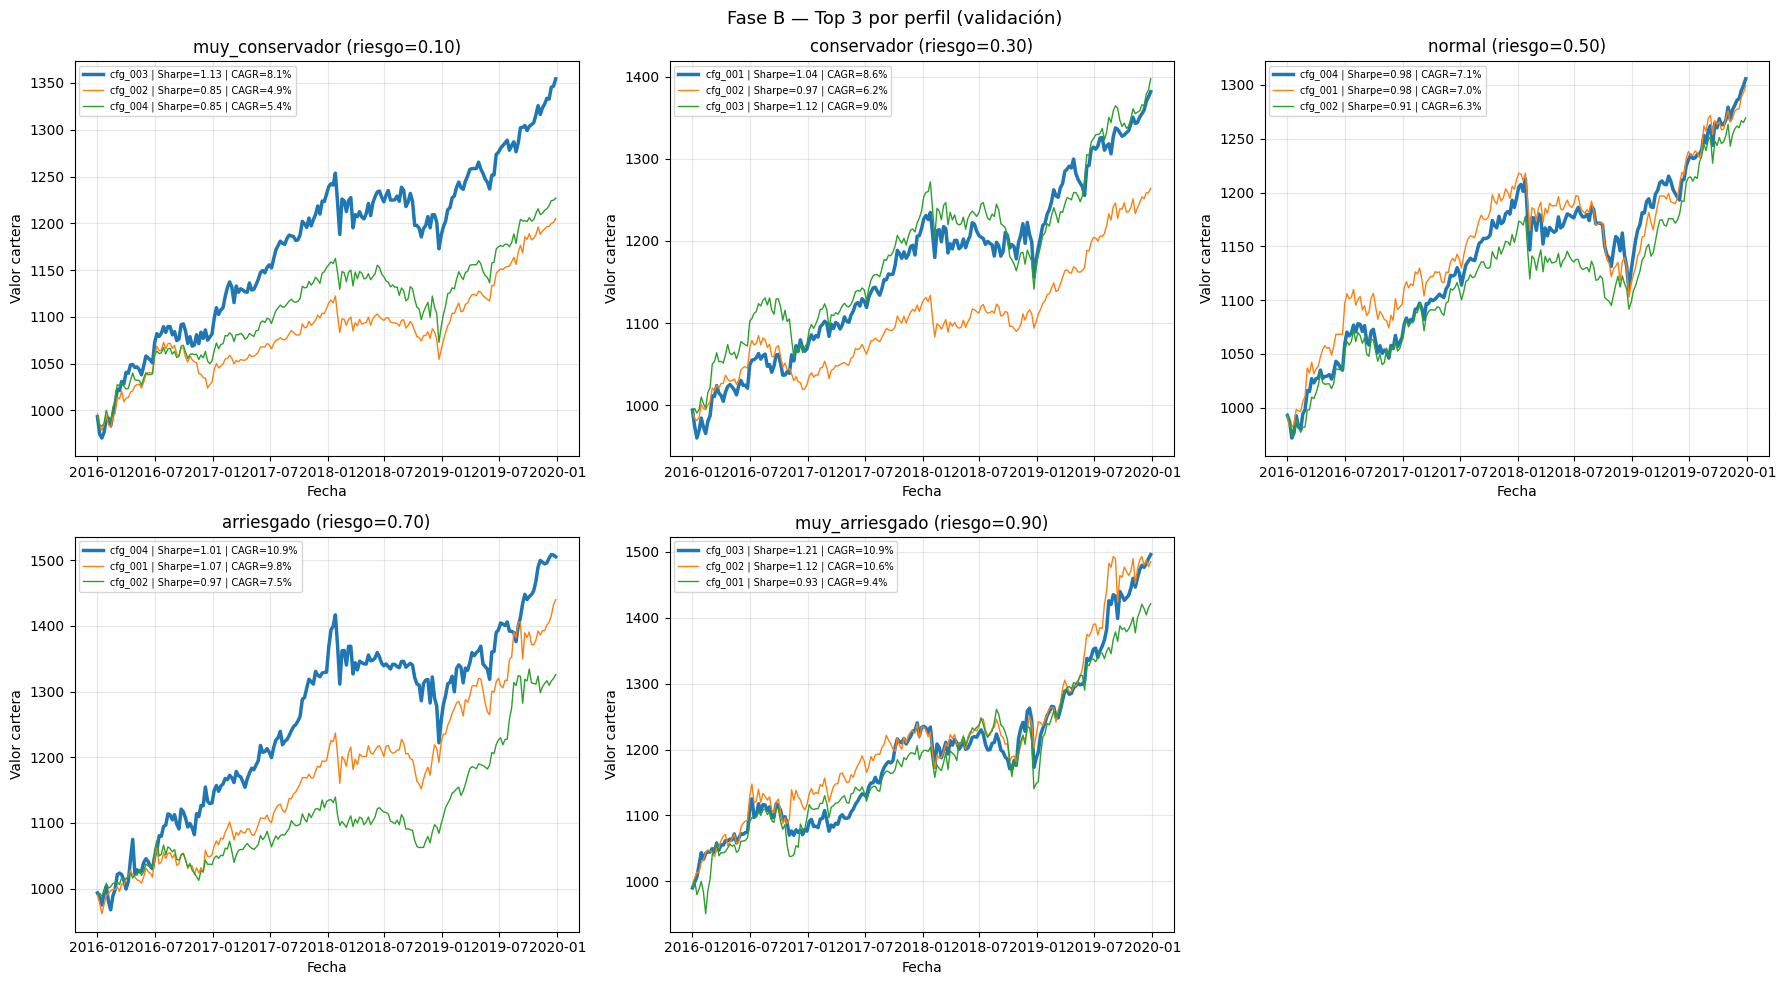

In [ ]:
# ------------------------------------------------------------------
# Gráfico: curva de validación del mejor por perfil (5 perfiles)
# ------------------------------------------------------------------
n_perfiles = len(finalistas_B)
ncols = 3
nrows = (n_perfiles + ncols - 1) // ncols  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, (perfil, finalistas) in enumerate(finalistas_B.items()):
    ax = axes[i]
    best_cfg_id = finalistas.iloc[0]["config_id"]
    curvas_perfil = curvas_B[perfil]

    # Top 3 curvas del perfil
    for j, row in finalistas.head(3).iterrows():
        cfg_id = row["config_id"]
        if cfg_id in curvas_perfil and curvas_perfil[cfg_id]:
            serie = curvas_perfil[cfg_id][0]
            lw = 2.5 if cfg_id == best_cfg_id else 1.0
            label = f"{cfg_id} | Sharpe={row['sharpe']:.2f} | CAGR={row['cagr']:.1%}"
            ax.plot(serie.index, serie.values, lw=lw, label=label)

    ax.set_title(f"{perfil} (riesgo={PERFILES_RIESGO[perfil]:.2f})")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor cartera")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Ocultar ejes sobrantes si ncols*nrows > n_perfiles
for j in range(n_perfiles, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Fase B — Top 3 por perfil (validación)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Verificar jerarquía de resultados
# ------------------------------------------------------------------
print("\n📈 Jerarquía de resultados (mejor por perfil):")
print(f"{'Perfil':<20} {'CAGR':>8} {'Sharpe':>8} {'MDD':>8}")
print("-" * 50)
for _, row in resumen_final_B.sort_values("riesgo").iterrows():
    print(
        f"{row['perfil']:<20} "
        f"{row['cagr']:>8.2%} "
        f"{row['sharpe']:>8.3f} "
        f"{row['max_drawdown']:>8.2%}"
    )

# Comprobar que CAGR crece con el riesgo
cagrs = resumen_final_B.sort_values("riesgo")["cagr"].values
jerarquia_ok = all(cagrs[i] <= cagrs[i+1] for i in range(len(cagrs)-1))
print(f"\n✅ Jerarquía CAGR correcta: {jerarquia_ok}")


📈 Jerarquía de resultados (mejor por perfil):
Perfil                   CAGR   Sharpe      MDD
--------------------------------------------------
muy_conservador         8.07%    1.133   -6.46%
conservador             8.57%    1.038   -6.37%
normal                  7.09%    0.982   -8.56%
arriesgado             10.94%    1.014  -13.75%
muy_arriesgado         10.87%    1.206   -7.12%

✅ Jerarquía CAGR correcta: False


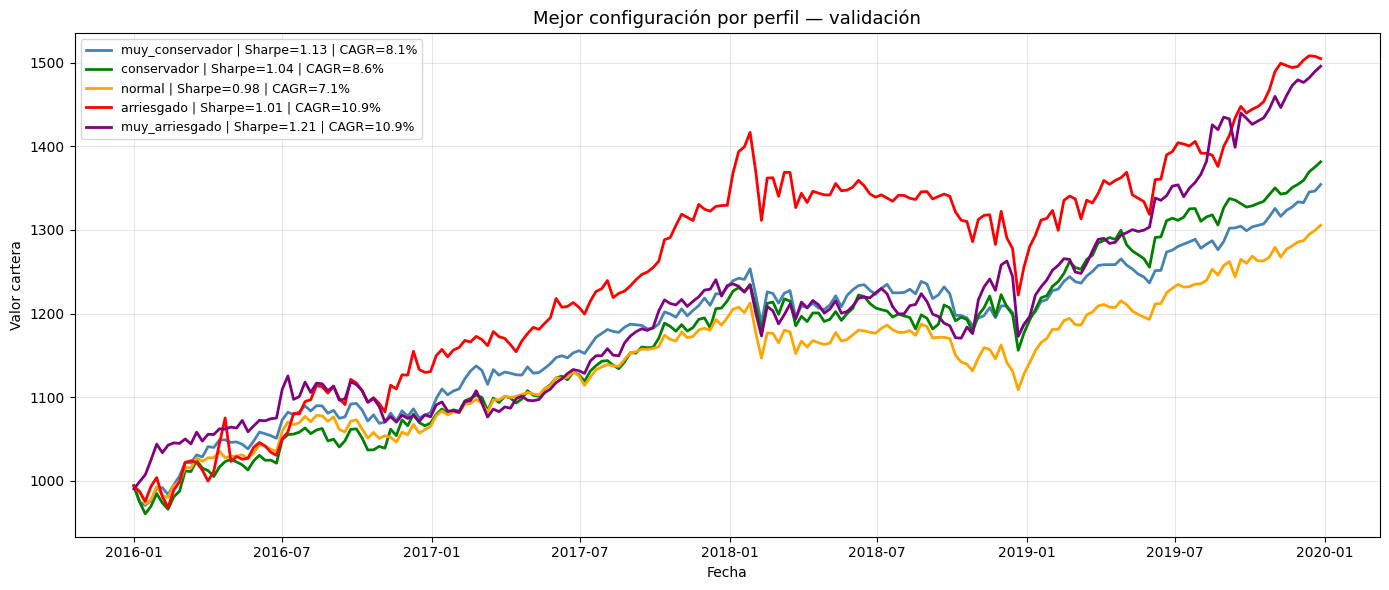

In [ ]:
# ------------------------------------------------------------------
# Gráfico único: mejor configuración de cada perfil superpuesta
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

colores = {
    "muy_conservador": "steelblue",
    "conservador":     "green",
    "normal":          "orange",
    "arriesgado":      "red",
    "muy_arriesgado":  "purple",
}

for perfil, finalistas in finalistas_B.items():
    best_cfg_id = finalistas.iloc[0]["config_id"]
    curvas_perfil = curvas_B[perfil]

    if best_cfg_id in curvas_perfil and curvas_perfil[best_cfg_id]:
        serie  = curvas_perfil[best_cfg_id][0]
        sharpe = finalistas.iloc[0]["sharpe"]
        cagr   = finalistas.iloc[0]["cagr"]
        ax.plot(
            serie.index, serie.values,
            lw=2,
            color=colores[perfil],
            label=f"{perfil} | Sharpe={sharpe:.2f} | CAGR={cagr:.1%}",
        )

ax.set_title("Mejor configuración por perfil — validación", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Fase C — Persistencia de configuraciones ganadoras

In [ ]:
# ------------------------------------------------------------------
# Guardar configuraciones ganadoras en JSON
# (directamente desde los ganadores de Fase B)
# ------------------------------------------------------------------
output_path = PROJECT_ROOT / "config_ganadora_hpo.json"

# Construir config_final_por_perfil desde los finalistas de Fase B
config_final_por_perfil = {}
for perfil, finalistas in finalistas_B.items():
    best = finalistas.iloc[0]
    cfg = copy.deepcopy(base_config_B)
    cfg["riesgo"] = float(PERFILES_RIESGO[perfil])
    for p in PARAMS_LAMBDA:
        if p in best.index:
            cfg[p] = best[p]
    config_final_por_perfil[perfil] = cfg

# Serializar
configs_json = {}
for perfil, cfg in config_final_por_perfil.items():
    configs_json[perfil] = {
        k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
        for k, v in cfg.items()
    }

with open(output_path, "w") as f:
    json.dump(configs_json, f, indent=2)

print(f"✅ Configuraciones guardadas en: {output_path}")
print("\nResumen de configuraciones finales:")

campos_mostrar = ["riesgo", "gamma", "tau", "lr_actor", "lr_criticos"] + PARAMS_LAMBDA
for perfil, cfg in configs_json.items():
    print(f"\n  [{perfil}]")
    for k in campos_mostrar:
        if k in cfg:
            print(f"    {k:35s} = {cfg[k]}")


✅ Configuraciones guardadas en: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/config_ganadora_hpo.json

Resumen de configuraciones finales:

  [muy_conservador]
    riesgo                              = 0.1
    gamma                               = 0.9
    tau                                 = 0.02
    lr_actor                            = 0.0003
    lr_criticos                         = 0.001
    lambda_dd                           = 0.6
    lambda_varianza                     = 0.1
    lambda_correlacion                  = 0.2

  [conservador]
    riesgo                              = 0.3
    gamma                               = 0.9
    tau                                 = 0.02
    lr_actor                            = 0.0003
    lr_criticos                         = 0.001
    lambda_dd                           = 0.2
    lambda_varianza                     = 0.1
    lambda_correlacion                  = 0.2

  [normal]
    riesgo              

In [ ]:
# ------------------------------------------------------------------
# Cómo cargar las configuraciones en el futuro
# ------------------------------------------------------------------
# with open(PROJECT_ROOT / "config_ganadora_hpo.json") as f:
#     configs = json.load(f)
#
# cfg_conservador = configs["conservador"]
# cfg_normal      = configs["normal"]
# cfg_arriesgado  = configs["arriesgado"]
# cfg_muy_arr     = configs["muy_arriesgado"]

print("Notebook HPO completo finalizado.")
print(f"Configuraciones guardadas en: {output_path}")

Notebook HPO completo finalizado.
Configuraciones guardadas en: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/config_ganadora_hpo.json
